# Project 4 — Fraud Detection / Anomaly Detection

## Credit Card Fraud Detection với Imbalanced Data

Notebook này được thiết kế để bạn học **Fraud Detection** theo kiểu từng bước, giống format Project 1, 2, 3 nhưng sẽ đi sâu hơn vào phần **imbalanced classification**.

Dataset gợi ý:

- Kaggle dataset: **Credit Card Fraud Detection**
- Kaggle slug: `mlg-ulb/creditcardfraud`
- File cần có: `creditcard.csv`

---

## Mục tiêu project

Sau project này, bạn cần hiểu và thực hành được:

1. Vì sao **Accuracy** rất dễ gây hiểu lầm trong bài toán fraud.
2. Cách đọc **Confusion Matrix** trong bài toán mất cân bằng dữ liệu.
3. Cách dùng **Precision / Recall / F1-score** đúng mục đích.
4. Cách dùng **ROC-AUC** và **PR-AUC / Average Precision**.
5. Cách xử lý **data imbalance** bằng:
   - `class_weight='balanced'`
   - `SMOTE`
6. Cách làm **threshold tuning** để thay đổi độ nhạy của model.
7. Cách lưu model và threshold để dùng lại sau này.

---

## Bài toán

Ta có các giao dịch thẻ tín dụng. Mỗi transaction có label:

- `Class = 0`: giao dịch bình thường
- `Class = 1`: giao dịch gian lận / fraud

Mục tiêu của model:

> Dự đoán giao dịch nào có khả năng là fraud.

Điểm khó nhất:

> Fraud cực kỳ ít so với normal transaction.

Vì vậy model chỉ cần đoán tất cả là `normal` cũng có thể đạt accuracy rất cao, nhưng thực tế lại vô dụng vì bỏ sót fraud.

# 0. Cấu trúc thư mục

Bạn nên đặt file như sau:

```text
Project_4_Fraud_Detection/
│
├── data/
│   └── creditcard.csv
│
├── models/
│   └── fraud_detection_model.pkl   # sẽ tạo sau
│
└── fraud_detection.ipynb
```

Nếu bạn dùng Kaggle CLI:

```bash
kaggle datasets download -d mlg-ulb/creditcardfraud
unzip creditcardfraud.zip -d data/
```

Sau khi giải nén, kiểm tra file:

```text
data/creditcard.csv
```

# 1. Cài thư viện cần thiết

Project này dùng thêm thư viện `imbalanced-learn` để dùng **SMOTE**.

Chạy cell dưới nếu máy bạn chưa có `imblearn`.

In [1]:
# Nếu đã cài rồi thì có thể bỏ qua cell này.
%pip install -q imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


# 2. Import thư viện

Ta dùng chủ yếu:

- `pandas`, `numpy`: xử lý dữ liệu
- `matplotlib`: vẽ biểu đồ
- `scikit-learn`: train/evaluate model
- `imblearn`: xử lý imbalanced data bằng SMOTE
- `joblib`: lưu model

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.base import clone

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import joblib

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

# 3. Config chung

Bạn có thể chỉnh các biến dưới đây nếu cần.

In [2]:
RANDOM_STATE = 42
TARGET = "Class"

BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "creditcard.csv"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(exist_ok=True)

# Random Forest có thể hơi chậm trên laptop yếu.
# Nếu chạy quá lâu, đổi thành False.
RUN_RANDOM_FOREST = True

# Isolation Forest là phần anomaly detection optional.
# Bạn nên học supervised models trước, sau đó mới bật phần này.
RUN_ISOLATION_FOREST = False

# 4. Load dataset

Dataset `creditcard.csv` thường có các cột:

- `Time`: thời gian tương đối của transaction
- `V1` đến `V28`: các feature đã được PCA/anonymized
- `Amount`: số tiền giao dịch
- `Class`: label, 0 là normal, 1 là fraud

Vì lý do bảo mật, dataset không cho biết ý nghĩa thật của `V1` đến `V28`.

In [3]:
# Tìm file ở một vài vị trí phổ biến để tránh lỗi đường dẫn.
if not DATA_PATH.exists():
    possible_paths = [
        BASE_DIR / "data" / "creditcard.csv"
    ]
    for path in possible_paths:
        if path.exists():
            DATA_PATH = path
            break

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Không tìm thấy creditcard.csv. Hãy đặt file vào data/creditcard.csv "
        "hoặc chỉnh biến DATA_PATH ở cell config."
    )

df = pd.read_csv(DATA_PATH)
print("Load dataset thành công!")
print("DATA_PATH:", DATA_PATH)
print("Shape:", df.shape)

df.head()

Load dataset thành công!
DATA_PATH: c:\Users\ASUS\Documents\PROJECT\intro_to_AI\data\creditcard.csv
Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# 5. Kiểm tra nhanh dữ liệu

Ở bước này ta kiểm tra:

- Dataset có bao nhiêu dòng, bao nhiêu cột.
- Kiểu dữ liệu của từng cột.
- Có missing values không.
- Có duplicate rows không.
- Target `Class` có đúng tồn tại không.

In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

if TARGET not in df.columns:
    raise ValueError(f"Không tìm thấy cột target '{TARGET}'. Hãy kiểm tra lại dataset.")

print("\nData types:")
display(df.dtypes.value_counts())

display(df.info())

Shape: (284807, 31)

Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:


float64    30
int64       1
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

None

In [5]:
missing = df.isna().sum().sort_values(ascending=False)
missing_percent = (missing / len(df) * 100).round(4)
missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_percent": missing_percent,
})

print("Số duplicate rows:", df.duplicated().sum())
display(missing_table.head(10))

Số duplicate rows: 1081


,missing_count,missing_percent
Time,0,0.0
V1,0,0.0
V2,0,0.0
V3,0,0.0
V4,0,0.0
V5,0,0.0
V6,0,0.0
V7,0,0.0
V8,0,0.0
V9,0,0.0


## Ghi chú quan trọng

Với dataset này, thường không có missing values và các feature chính đã được xử lý sẵn.

Nhưng ta vẫn kiểm tra vì trong project thật, dữ liệu tài chính có thể có:

- missing values
- duplicate transactions
- transaction lỗi
- data leakage
- feature không được scale
- label không cân bằng cực nặng

# 6. Kiểm tra imbalanced data

Đây là phần quan trọng nhất của project này.

Nếu fraud chỉ chiếm khoảng 0.1% đến 0.2%, model đoán tất cả là normal vẫn đạt accuracy rất cao.

Ví dụ:

Nếu có 100,000 giao dịch:

- 99,800 normal
- 200 fraud

Model đoán tất cả là normal:

- Accuracy = 99.8%
- Nhưng Recall fraud = 0%

Model này nhìn rất tốt trên Accuracy, nhưng thực tế không bắt được vụ fraud nào.

In [6]:
class_counts = df[TARGET].value_counts().sort_index()
class_ratio = df[TARGET].value_counts(normalize=True).sort_index()

class_summary = pd.DataFrame({
    "class_name": ["Normal", "Fraud"],
    "count": class_counts.values,
    "ratio": class_ratio.values,
    "percent": (class_ratio.values * 100).round(4),
}, index=class_counts.index)

class_summary.index.name = "Class"
display(class_summary)

fraud_rate = class_ratio.loc[1]
print(f"Fraud rate: {fraud_rate:.6f} = {fraud_rate * 100:.4f}%")

,class_name,count,ratio,percent
Class,,,,
0,Normal,284315,0.998273,99.8273
1,Fraud,492,0.001727,0.1727


Fraud rate: 0.001727 = 0.1727%


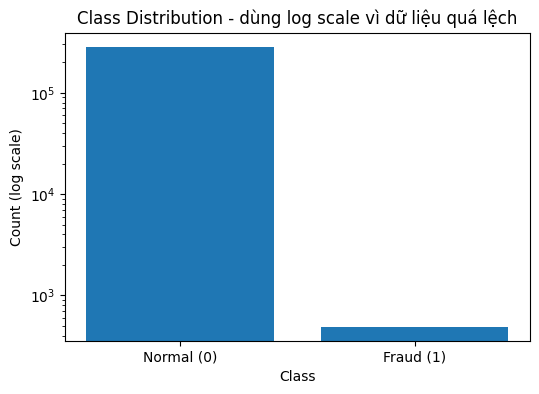

In [7]:
plt.figure(figsize=(6, 4))
plt.bar(["Normal (0)", "Fraud (1)"], class_counts.values)
plt.yscale("log")
plt.title("Class Distribution - dùng log scale vì dữ liệu quá lệch")
plt.ylabel("Count (log scale)")
plt.xlabel("Class")
plt.show()

# 7. EDA cơ bản

Vì các cột `V1` đến `V28` đã được PCA/anonymized, ta không thể giải thích business meaning của từng cột.

Nhưng ta vẫn có thể phân tích:

- `Amount`: số tiền giao dịch
- `Time`: thời điểm tương đối
- phân phối của một số feature theo class
- correlation với target

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## 7.1 Phân phối Amount

Ta dùng `log1p(Amount)` thay vì `Amount` trực tiếp vì Amount thường bị skew mạnh.

`log1p(x) = log(1 + x)` giúp biểu đồ dễ nhìn hơn khi có giá trị rất lớn.

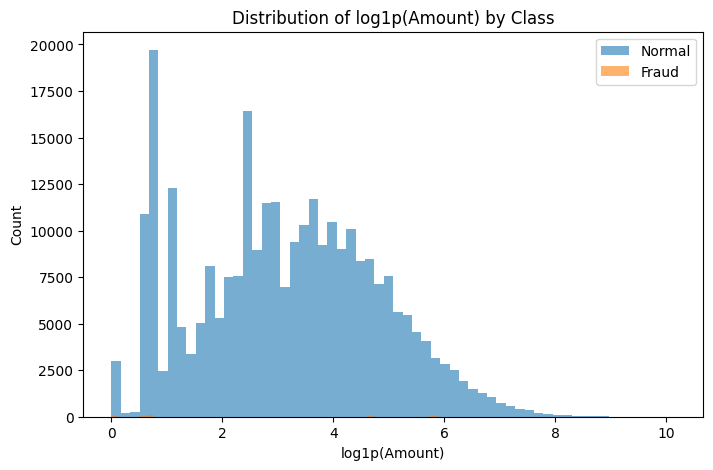

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [9]:
normal_amount = df.loc[df[TARGET] == 0, "Amount"]
fraud_amount = df.loc[df[TARGET] == 1, "Amount"]

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(normal_amount), bins=60, alpha=0.6, label="Normal")
plt.hist(np.log1p(fraud_amount), bins=60, alpha=0.6, label="Fraud")
plt.title("Distribution of log1p(Amount) by Class")
plt.xlabel("log1p(Amount)")
plt.ylabel("Count")
plt.legend()
plt.show()

amount_summary = df.groupby(TARGET)["Amount"].describe()
display(amount_summary)

## 7.2 Phân phối Time

`Time` là thời gian tương đối từ transaction đầu tiên.

Ta không dùng nó như ngày giờ thật, nhưng vẫn có thể xem fraud có xuất hiện nhiều ở một vùng thời gian nào không.

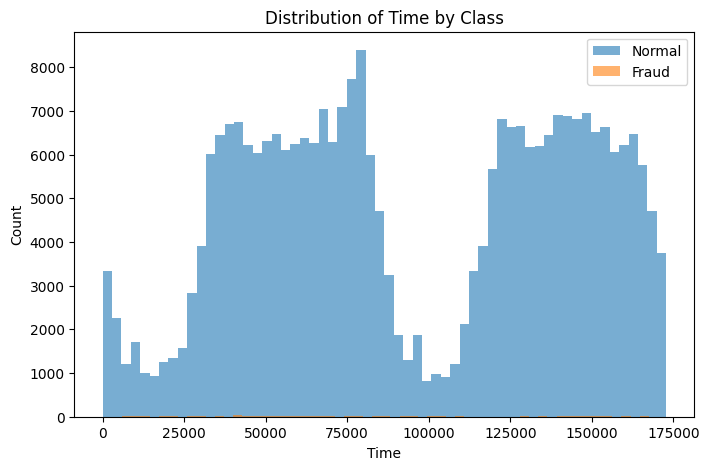

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(df.loc[df[TARGET] == 0, "Time"], bins=60, alpha=0.6, label="Normal")
plt.hist(df.loc[df[TARGET] == 1, "Time"], bins=60, alpha=0.6, label="Fraud")
plt.title("Distribution of Time by Class")
plt.xlabel("Time")
plt.ylabel("Count")
plt.legend()
plt.show()

## 7.3 Correlation với target

Correlation không chứng minh quan hệ nhân quả, nhưng giúp ta xem feature nào có liên hệ tuyến tính mạnh hơn với `Class`.

Top 15 features có absolute correlation cao nhất với Class:


,corr_with_Class
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V11,0.154876
V4,0.133447
V18,-0.111485


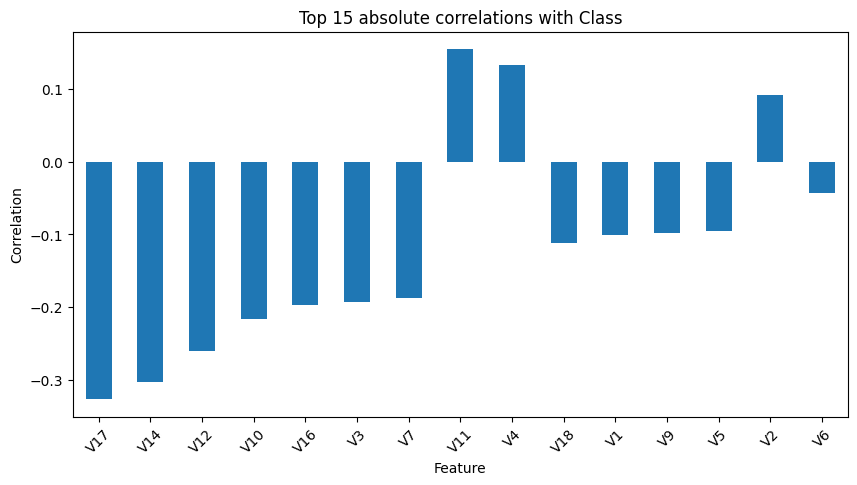

In [11]:
corr_with_target = df.corr(numeric_only=True)[TARGET].drop(TARGET)
corr_abs = corr_with_target.reindex(corr_with_target.abs().sort_values(ascending=False).index)

print("Top 15 features có absolute correlation cao nhất với Class:")
display(corr_abs.head(15).to_frame("corr_with_Class"))

plt.figure(figsize=(10, 5))
corr_abs.head(15).plot(kind="bar")
plt.title("Top 15 absolute correlations with Class")
plt.ylabel("Correlation")
plt.xlabel("Feature")
plt.xticks(rotation=45)
plt.show()

# 8. Tách X, y

- `X`: toàn bộ feature dùng để dự đoán
- `y`: label fraud/normal

Không được để cột `Class` nằm trong `X`, vì như vậy là **data leakage**.

In [12]:
X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Features:", X.columns.tolist())

X shape: (284807, 30)
y shape: (284807,)
Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


# 9. Train / Validation / Test Split

Ta chia dữ liệu thành 3 phần:

1. **Train set**: dùng để train model.
2. **Validation set**: dùng để chọn threshold.
3. **Test set**: chỉ dùng cuối cùng để đánh giá thật.

Vì fraud rất ít, ta bắt buộc dùng `stratify=y` để giữ tỷ lệ fraud tương đối giống nhau ở train/validation/test.

Quy tắc quan trọng:

> Test set không được dùng để tuning threshold hoặc chọn model nhiều lần.

In [13]:
# 80% train_temp, 20% test
X_train_temp, X_test, y_train_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

# Từ train_temp tách tiếp: 75% train, 25% validation
# Tổng thể: train 60%, validation 20%, test 20%
X_train, X_val, y_train, y_val = train_test_split(
    X_train_temp,
    y_train_temp,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_temp,
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (170883, 30) (170883,)
Validation: (56962, 30) (56962,)
Test: (56962, 30) (56962,)


In [14]:
def class_distribution(name, y_part):
    counts = y_part.value_counts().sort_index()
    ratios = y_part.value_counts(normalize=True).sort_index()
    return pd.DataFrame({
        "split": name,
        "class": counts.index,
        "count": counts.values,
        "percent": (ratios.values * 100).round(4),
    })

split_distribution = pd.concat([
    class_distribution("train", y_train),
    class_distribution("validation", y_val),
    class_distribution("test", y_test),
], ignore_index=True)

display(split_distribution)

,split,class,count,percent
0,train,0,170588,99.8274
1,train,1,295,0.1726
2,validation,0,56863,99.8262
3,validation,1,99,0.1738
4,test,0,56864,99.8280
5,test,1,98,0.1720


# 10. Preprocessing

Trong dataset này:

- `V1` đến `V28` thường đã được PCA và scale/anonymized.
- `Time` và `Amount` chưa chắc đã scale.

Vì vậy ta sẽ scale `Time` và `Amount` bằng `StandardScaler`.

Lưu ý:

- Với Logistic Regression, scaling rất quan trọng.
- Với Random Forest, scaling không quá quan trọng, nhưng để pipeline thống nhất thì vẫn giữ preprocessing.

In [15]:
def make_preprocessor():
    cols_to_scale = [col for col in ["Time", "Amount"] if col in X.columns]
    
    preprocessor = ColumnTransformer(
        transformers=[
            ("scale_time_amount", StandardScaler(), cols_to_scale),
        ],
        remainder="passthrough",
        verbose_feature_names_out=False,
    )
    return preprocessor

preprocessor = make_preprocessor()
print(preprocessor)

ColumnTransformer(remainder='passthrough',
                  transformers=[('scale_time_amount', StandardScaler(),
                                 ['Time', 'Amount'])],
                  verbose_feature_names_out=False)


# 11. Evaluation functions

Ta sẽ tạo hàm đánh giá để dùng lại cho nhiều model.

Các metric chính:

## Accuracy
Tỷ lệ dự đoán đúng toàn bộ.

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

Với imbalanced data, accuracy dễ gây hiểu lầm.

## Precision
Trong các giao dịch model báo là fraud, có bao nhiêu giao dịch thật sự là fraud?

$$
Precision = \frac{TP}{TP + FP}
$$

Precision thấp nghĩa là model báo động giả nhiều.

## Recall
Trong các fraud thật sự, model bắt được bao nhiêu?

$$
Recall = \frac{TP}{TP + FN}
$$

Recall thấp nghĩa là model bỏ sót fraud nhiều.

## F1-score
Trung bình điều hòa giữa Precision và Recall.

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

## ROC-AUC
Đánh giá khả năng model xếp fraud cao hơn normal trên nhiều threshold.

## PR-AUC / Average Precision
Rất quan trọng khi dữ liệu mất cân bằng nặng. Với fraud detection, PR-AUC thường đáng xem hơn ROC-AUC.

In [16]:
def get_metrics(y_true, y_proba, threshold=0.5, model_name="model"):
    '''Return common classification metrics for fraud detection.'''
    y_pred = (y_proba >= threshold).astype(int)
    
    metrics = {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc_avg_precision": average_precision_score(y_true, y_proba),
    }
    return metrics


def evaluate_predictions(y_true, y_proba, threshold=0.5, model_name="model", plot=True):
    '''Print metrics, classification report, and optionally plot confusion matrix/curves.'''
    y_pred = (y_proba >= threshold).astype(int)
    metrics = get_metrics(y_true, y_proba, threshold, model_name)
    
    print(f"===== {model_name} | threshold = {threshold:.4f} =====")
    for key, value in metrics.items():
        if key not in ["model", "threshold"]:
            print(f"{key}: {value:.6f}")
    
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4, zero_division=0))
    
    if plot:
        ConfusionMatrixDisplay.from_predictions(
            y_true,
            y_pred,
            display_labels=["Normal", "Fraud"],
            values_format="d",
        )
        plt.title(f"Confusion Matrix - {model_name}")
        plt.show()
        
        RocCurveDisplay.from_predictions(y_true, y_proba)
        plt.title(f"ROC Curve - {model_name}")
        plt.show()
        
        PrecisionRecallDisplay.from_predictions(y_true, y_proba)
        plt.title(f"Precision-Recall Curve - {model_name}")
        plt.show()
    
    return metrics

# 12. Baseline cực đơn giản: đoán tất cả là Normal

Đây là baseline để thấy vì sao Accuracy nguy hiểm.

Model này không cần học gì cả, chỉ đoán mọi transaction là `0`.

Ta kỳ vọng:

- Accuracy rất cao
- Precision = 0
- Recall = 0
- F1 = 0

Vì nó không bắt được fraud nào.

===== always_normal_baseline | threshold = 0.5000 =====
accuracy: 0.998262
balanced_accuracy: 0.500000
precision: 0.000000
recall: 0.000000
f1: 0.000000
roc_auc: 0.500000
pr_auc_avg_precision: 0.001738

Classification report:
              precision    recall  f1-score   support

           0     0.9983    1.0000    0.9991     56863
           1     0.0000    0.0000    0.0000        99

    accuracy                         0.9983     56962
   macro avg     0.4991    0.5000    0.4996     56962
weighted avg     0.9965    0.9983    0.9974     56962



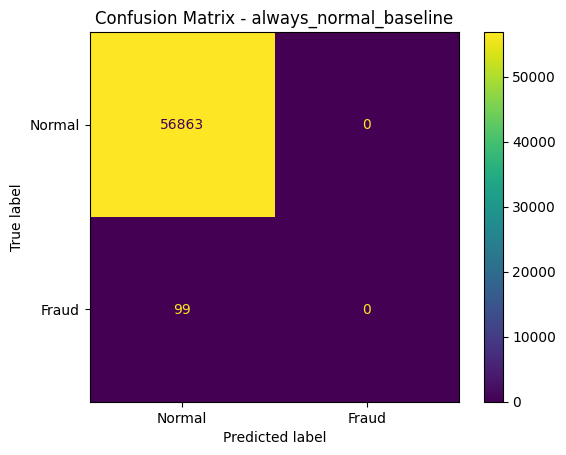

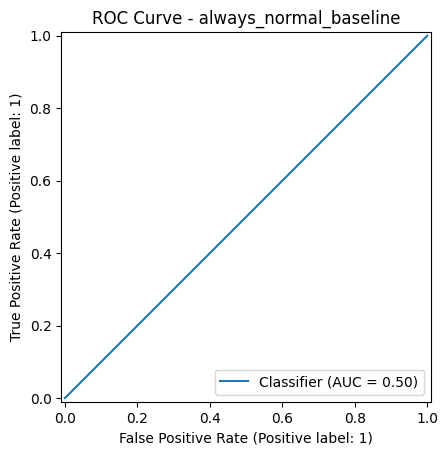

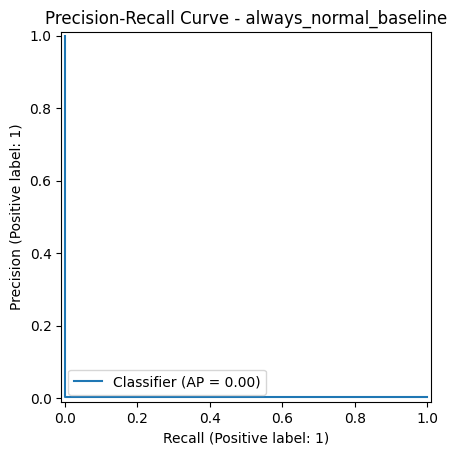

In [17]:
baseline_val_proba = np.zeros(len(y_val))

results = []
baseline_metrics = evaluate_predictions(
    y_val,
    baseline_val_proba,
    threshold=0.5,
    model_name="always_normal_baseline",
    plot=True,
)
results.append(baseline_metrics)

# 13. Model 1 — Logistic Regression cơ bản

Đây là model baseline có học thật.

Ta chưa dùng `class_weight` và chưa dùng `SMOTE`.

Mục đích:

> Xem model thường hoạt động ra sao khi dữ liệu bị lệch class nặng.

In [18]:
models = {}


def train_and_evaluate(model_name, pipeline, X_train, y_train, X_val, y_val):
    print(f"Training: {model_name}")
    pipeline.fit(X_train, y_train)
    y_val_proba = pipeline.predict_proba(X_val)[:, 1]
    metrics = evaluate_predictions(
        y_val,
        y_val_proba,
        threshold=0.5,
        model_name=model_name,
        plot=True,
    )
    models[model_name] = pipeline
    results.append(metrics)
    return pipeline, metrics

Training: logistic_regression_basic
===== logistic_regression_basic | threshold = 0.5000 =====
accuracy: 0.998999
balanced_accuracy: 0.767580
precision: 0.828125
recall: 0.535354
f1: 0.650307
roc_auc: 0.964581
pr_auc_avg_precision: 0.708266

Classification report:
              precision    recall  f1-score   support

           0     0.9992    0.9998    0.9995     56863
           1     0.8281    0.5354    0.6503        99

    accuracy                         0.9990     56962
   macro avg     0.9137    0.7676    0.8249     56962
weighted avg     0.9989    0.9990    0.9989     56962



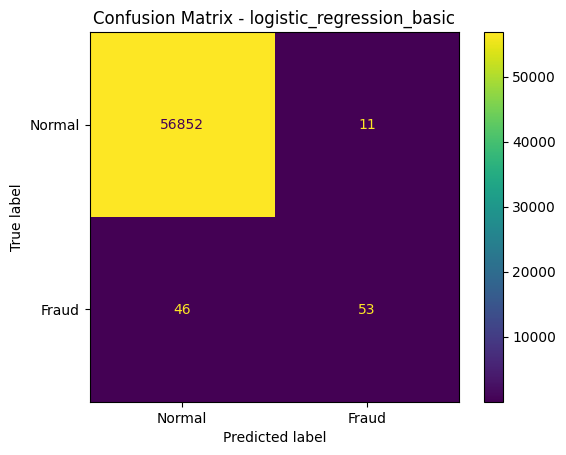

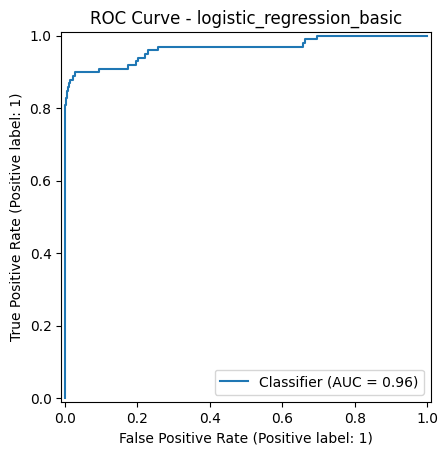

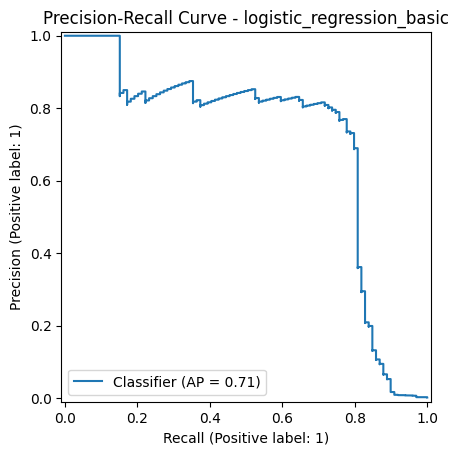

In [19]:
lr_basic = SklearnPipeline(steps=[
    ("preprocess", make_preprocessor()),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

lr_basic, lr_basic_metrics = train_and_evaluate(
    "logistic_regression_basic",
    lr_basic,
    X_train,
    y_train,
    X_val,
    y_val,
)

# 14. Model 2 — Logistic Regression với class_weight='balanced'

`class_weight='balanced'` làm model phạt lỗi ở class hiếm mạnh hơn.

Ý tưởng trực giác:

- Fraud ít quá, nếu model bỏ qua fraud thì vẫn có loss nhỏ.
- Ta tăng trọng số lỗi fraud để model quan tâm đến fraud hơn.

Ưu điểm:

- Dễ dùng.
- Không tạo dữ liệu giả.
- Ít nguy cơ data leakage hơn nếu dùng đúng pipeline.

Nhược điểm:

- Có thể tăng Recall nhưng giảm Precision.

Training: logistic_regression_class_weight_balanced
===== logistic_regression_class_weight_balanced | threshold = 0.5000 =====
accuracy: 0.974931
balanced_accuracy: 0.937026
precision: 0.059058
recall: 0.898990
f1: 0.110834
roc_auc: 0.974666
pr_auc_avg_precision: 0.683091

Classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9751    0.9873     56863
           1     0.0591    0.8990    0.1108        99

    accuracy                         0.9749     56962
   macro avg     0.5294    0.9370    0.5491     56962
weighted avg     0.9982    0.9749    0.9858     56962



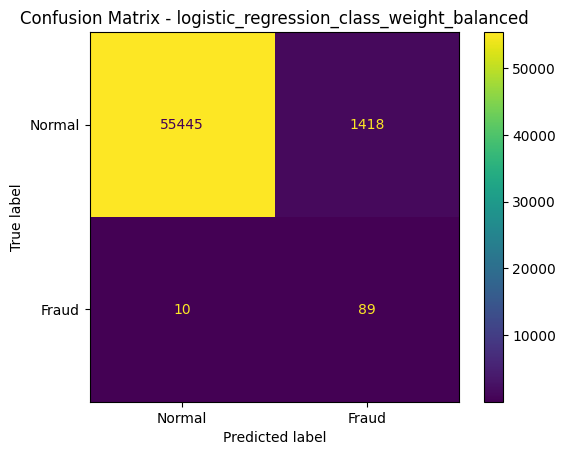

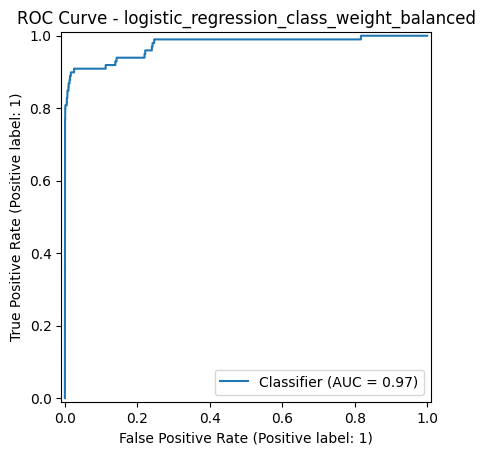

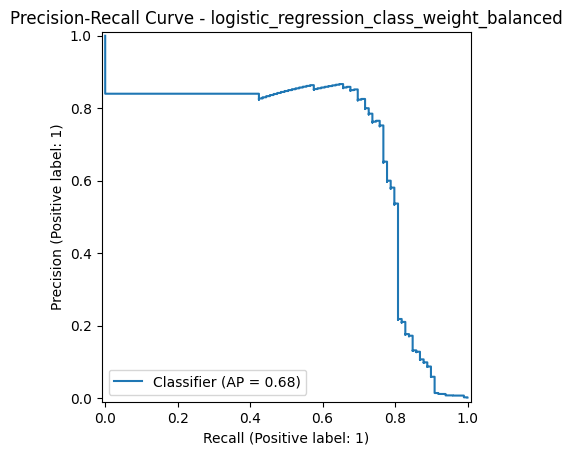

In [20]:
lr_balanced = SklearnPipeline(steps=[
    ("preprocess", make_preprocessor()),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

lr_balanced, lr_balanced_metrics = train_and_evaluate(
    "logistic_regression_class_weight_balanced",
    lr_balanced,
    X_train,
    y_train,
    X_val,
    y_val,
)

# 15. Model 3 — Logistic Regression + SMOTE

## SMOTE là gì?

**SMOTE** = Synthetic Minority Oversampling Technique.

Thay vì copy fraud samples y nguyên, SMOTE tạo ra sample fraud mới bằng cách nội suy giữa các fraud samples gần nhau.

Ví dụ đơn giản:

```text
Fraud A -------- Fraud B
        ↑
   synthetic fraud
```

## Quy tắc cực kỳ quan trọng

Không được dùng SMOTE trước khi train/test split.

Sai:

```text
Full data -> SMOTE -> train/test split
```

Vì synthetic samples có thể làm thông tin từ test leak vào train.

Đúng:

```text
Train/test split -> SMOTE chỉ trên train -> train model -> evaluate trên validation/test thật
```

Trong notebook này, ta dùng `imblearn.pipeline.Pipeline` để đảm bảo SMOTE chỉ được áp dụng trong training data.

Training: smote_logistic_regression
===== smote_logistic_regression | threshold = 0.5000 =====
accuracy: 0.974439
balanced_accuracy: 0.926697
precision: 0.056826
recall: 0.878788
f1: 0.106748
roc_auc: 0.971637
pr_auc_avg_precision: 0.673732

Classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9746    0.9870     56863
           1     0.0568    0.8788    0.1067        99

    accuracy                         0.9744     56962
   macro avg     0.5283    0.9267    0.5469     56962
weighted avg     0.9981    0.9744    0.9855     56962



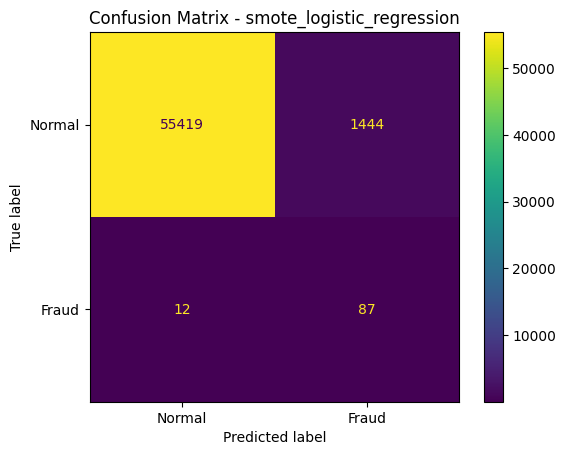

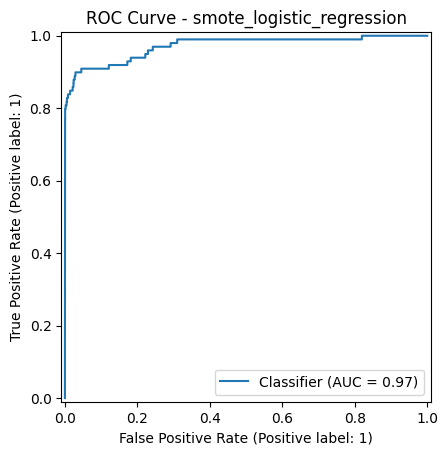

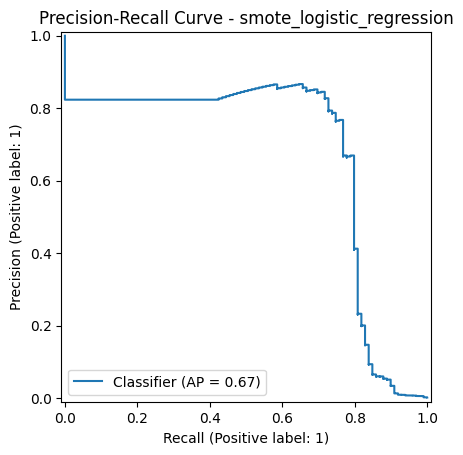

In [21]:
smote_lr = ImbPipeline(steps=[
    ("preprocess", make_preprocessor()),
    ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
])

smote_lr, smote_lr_metrics = train_and_evaluate(
    "smote_logistic_regression",
    smote_lr,
    X_train,
    y_train,
    X_val,
    y_val,
)

# 16. Model 4 — Random Forest với class_weight

Random Forest thường mạnh hơn Logistic Regression vì học được quan hệ phi tuyến.

Trong fraud detection, Random Forest có thể tốt, nhưng:

- Train chậm hơn.
- Khó giải thích hơn Logistic Regression.
- Có thể cần tuning nhiều hơn.

Cell dưới có thể mất thời gian. Nếu máy yếu, đặt:

```python
RUN_RANDOM_FOREST = False
```

Training: random_forest_class_weight_balanced
===== random_forest_class_weight_balanced | threshold = 0.5000 =====
accuracy: 0.999386
balanced_accuracy: 0.838357
precision: 0.957143
recall: 0.676768
f1: 0.792899
roc_auc: 0.942228
pr_auc_avg_precision: 0.806545

Classification report:
              precision    recall  f1-score   support

           0     0.9994    0.9999    0.9997     56863
           1     0.9571    0.6768    0.7929        99

    accuracy                         0.9994     56962
   macro avg     0.9783    0.8384    0.8963     56962
weighted avg     0.9994    0.9994    0.9993     56962



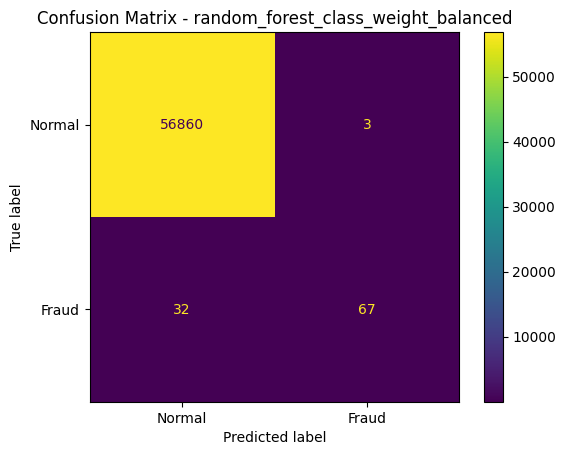

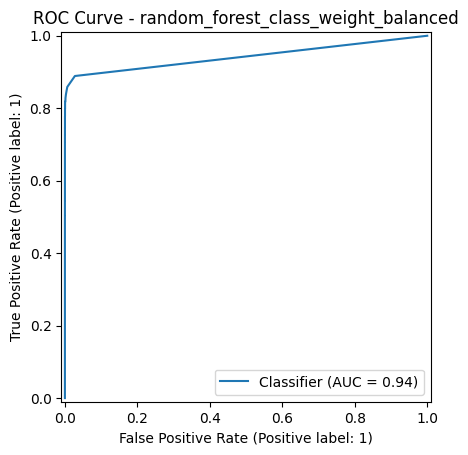

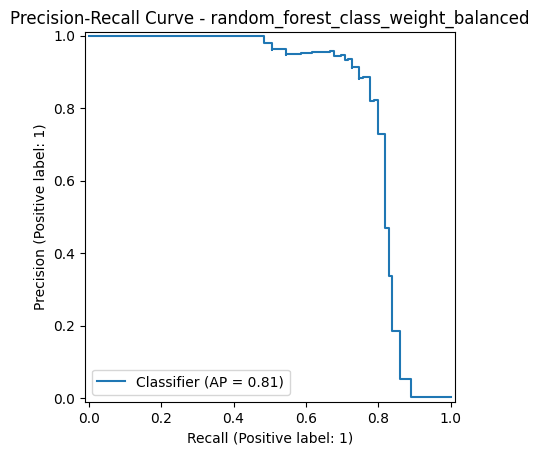

In [22]:
if RUN_RANDOM_FOREST:
    rf_balanced = SklearnPipeline(steps=[
        ("preprocess", make_preprocessor()),
        ("model", RandomForestClassifier(
            n_estimators=150,
            max_depth=None,
            min_samples_leaf=1,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])
    
    rf_balanced, rf_balanced_metrics = train_and_evaluate(
        "random_forest_class_weight_balanced",
        rf_balanced,
        X_train,
        y_train,
        X_val,
        y_val,
    )
else:
    print("Bỏ qua Random Forest vì RUN_RANDOM_FOREST = False")

# 17. So sánh model trên validation set

Ta sẽ so sánh các model bằng bảng metric.

Với fraud detection, chú ý nhất:

1. **Recall**: bắt được bao nhiêu fraud thật.
2. **Precision**: cảnh báo fraud có đáng tin không.
3. **PR-AUC / Average Precision**: rất hữu ích khi class fraud cực ít.
4. **ROC-AUC**: vẫn xem, nhưng không nên chỉ dựa vào nó.

Accuracy không phải metric chính ở đây.

In [23]:
compare_df = pd.DataFrame(results)
compare_df = compare_df.sort_values(by="pr_auc_avg_precision", ascending=False)

display(compare_df)

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc_avg_precision
4,random_forest_class_weight_balanced,0.5,0.999386,0.838357,0.957143,0.676768,0.792899,0.942228,0.806545
1,logistic_regression_basic,0.5,0.998999,0.767580,0.828125,0.535354,0.650307,0.964581,0.708266
2,logistic_regression_class_weight_balanced,0.5,0.974931,0.937026,0.059058,0.898990,0.110834,0.974666,0.683091
3,smote_logistic_regression,0.5,0.974439,0.926697,0.056826,0.878788,0.106748,0.971637,0.673732
0,always_normal_baseline,0.5,0.998262,0.500000,0.000000,0.000000,0.000000,0.500000,0.001738


# 18. Threshold tuning

Mặc định binary classification thường dùng threshold = 0.5:

```text
p(fraud) >= 0.5 -> Fraud
p(fraud) < 0.5  -> Normal
```

Nhưng trong fraud detection, threshold 0.5 chưa chắc tốt.

Nếu giảm threshold:

- Model dễ báo fraud hơn.
- Recall thường tăng.
- Precision thường giảm.

Nếu tăng threshold:

- Model khó báo fraud hơn.
- Precision có thể tăng.
- Recall thường giảm.

Đây là trade-off quan trọng.

In [24]:
def threshold_search(y_true, y_proba, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.01, 1.00, 0.01)
    
    rows = []
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        rows.append({
            "threshold": threshold,
            "accuracy": accuracy_score(y_true, y_pred),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "predicted_fraud_count": int(y_pred.sum()),
        })
    
    return pd.DataFrame(rows)

In [25]:
# Chọn model để tuning threshold.
# Bạn có thể đổi tên model dựa trên compare_df phía trên.
CANDIDATE_MODEL_NAME = "smote_logistic_regression"

if CANDIDATE_MODEL_NAME not in models:
    CANDIDATE_MODEL_NAME = list(models.keys())[0]
    print("Model mặc định không tồn tại, chuyển sang:", CANDIDATE_MODEL_NAME)

candidate_model = models[CANDIDATE_MODEL_NAME]
y_val_proba_candidate = candidate_model.predict_proba(X_val)[:, 1]

threshold_df = threshold_search(y_val, y_val_proba_candidate)

print("Top 10 threshold theo F1-score:")
display(threshold_df.sort_values(by="f1", ascending=False).head(10))

Top 10 threshold theo F1-score:


,threshold,accuracy,balanced_accuracy,precision,recall,f1,predicted_fraud_count
98,0.99,0.997999,0.898163,0.456647,0.797980,0.580882,173
97,0.98,0.996787,0.902598,0.327869,0.808081,0.466472,244
96,0.97,0.995927,0.902167,0.273038,0.808081,0.408163,293
95,0.96,0.995453,0.901930,0.250000,0.808081,0.381862,320
94,0.95,0.994979,0.901693,0.230548,0.808081,0.358744,347
93,0.94,0.994716,0.906602,0.222527,0.818182,0.349892,364
92,0.93,0.994242,0.906365,0.207161,0.818182,0.330612,391
91,0.92,0.993961,0.906224,0.199017,0.818182,0.320158,407
90,0.91,0.993627,0.911099,0.191589,0.828283,0.311195,428
89,0.90,0.993294,0.910932,0.183445,0.828283,0.300366,447


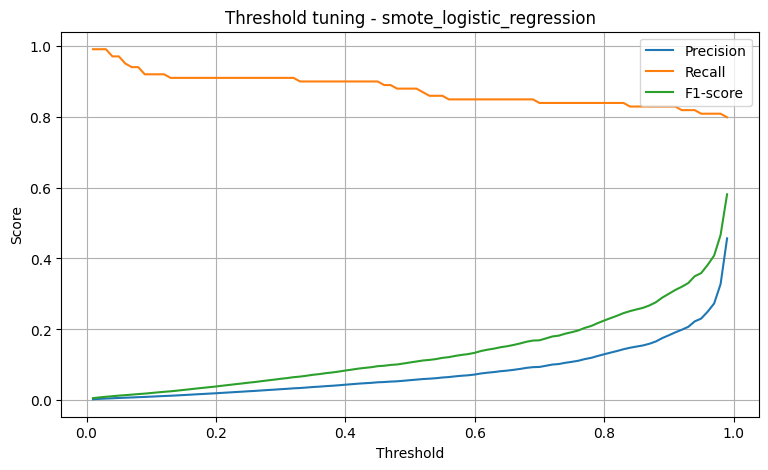

In [26]:
plt.figure(figsize=(9, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1-score")
plt.title(f"Threshold tuning - {CANDIDATE_MODEL_NAME}")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(True)
plt.show()

## 18.1 Chọn threshold theo chiến lược

Có nhiều cách chọn threshold:

### Cách 1: Max F1
Phù hợp khi bạn muốn cân bằng Precision và Recall.

### Cách 2: Target Recall
Phù hợp khi fraud detection ưu tiên bắt fraud nhiều nhất có thể.

Ví dụ:

> Muốn Recall ít nhất 90%, sau đó chọn threshold có Precision cao nhất trong nhóm đạt Recall >= 90%.

Trong thực tế, chọn threshold phụ thuộc vào business cost:

- Bỏ sót fraud tốn bao nhiêu tiền?
- Báo động giả khiến đội kiểm tra mất bao nhiêu thời gian?

In [27]:
# Strategy 1: threshold có F1 cao nhất
best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]

# Strategy 2: threshold đạt target recall, sau đó chọn precision cao nhất
TARGET_RECALL = 0.90
valid_recall_df = threshold_df[threshold_df["recall"] >= TARGET_RECALL]

if len(valid_recall_df) > 0:
    best_target_recall_row = valid_recall_df.sort_values(
        by=["precision", "f1"],
        ascending=False,
    ).iloc[0]
else:
    best_target_recall_row = threshold_df.loc[threshold_df["recall"].idxmax()]

selection_table = pd.DataFrame([
    {"strategy": "max_f1", **best_f1_row.to_dict()},
    {"strategy": f"target_recall_{TARGET_RECALL}", **best_target_recall_row.to_dict()},
])

display(selection_table)

,strategy,threshold,accuracy,balanced_accuracy,precision,recall,f1,predicted_fraud_count
0,max_f1,0.99,0.997999,0.898163,0.456647,0.797980,0.580882,173.0
1,target_recall_0.9,0.32,0.954759,0.931965,0.033860,0.909091,0.065288,2658.0


In [28]:
# Chọn strategy cuối cùng.
# Bạn có thể đổi thành "max_f1" nếu muốn cân bằng hơn.
SELECTED_STRATEGY = "target_recall"

if SELECTED_STRATEGY == "max_f1":
    selected_threshold = float(best_f1_row["threshold"])
else:
    selected_threshold = float(best_target_recall_row["threshold"])

print("Selected model:", CANDIDATE_MODEL_NAME)
print("Selected strategy:", SELECTED_STRATEGY)
print("Selected threshold:", selected_threshold)

Selected model: smote_logistic_regression
Selected strategy: target_recall
Selected threshold: 0.32


# 19. Đánh giá cuối cùng trên Test Set

Bây giờ mới dùng test set.

Ta sẽ so sánh:

1. Candidate model với threshold mặc định 0.5
2. Candidate model với threshold đã tuning

Nếu threshold tuning tốt, bạn thường sẽ thấy Recall/Precision thay đổi rõ.

Đánh giá với threshold mặc định 0.5
===== smote_logistic_regression_test_default_threshold | threshold = 0.5000 =====
accuracy: 0.974896
balanced_accuracy: 0.936494
precision: 0.058355
recall: 0.897959
f1: 0.109589
roc_auc: 0.972005
pr_auc_avg_precision: 0.724059

Classification report:
              precision    recall  f1-score   support

           0     0.9998    0.9750    0.9873     56864
           1     0.0584    0.8980    0.1096        98

    accuracy                         0.9749     56962
   macro avg     0.5291    0.9365    0.5484     56962
weighted avg     0.9982    0.9749    0.9858     56962



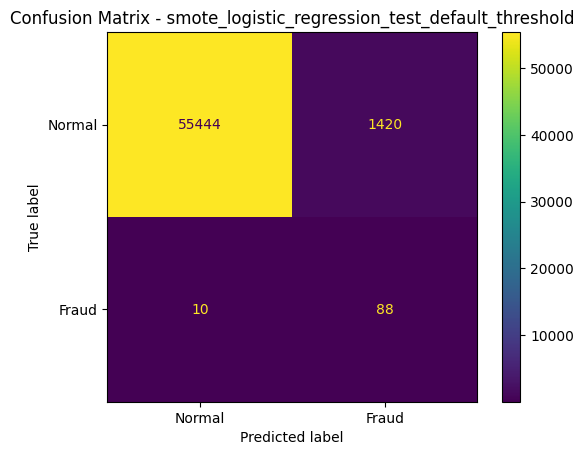

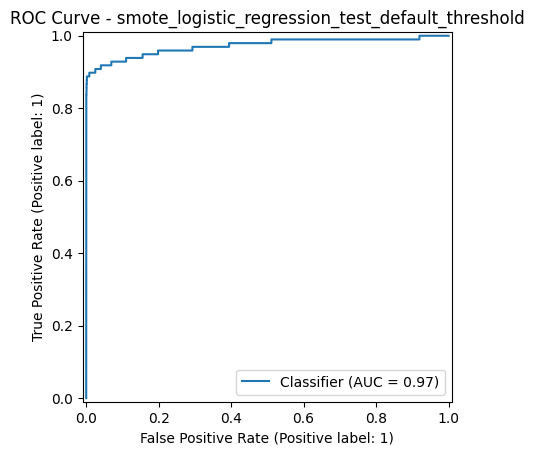

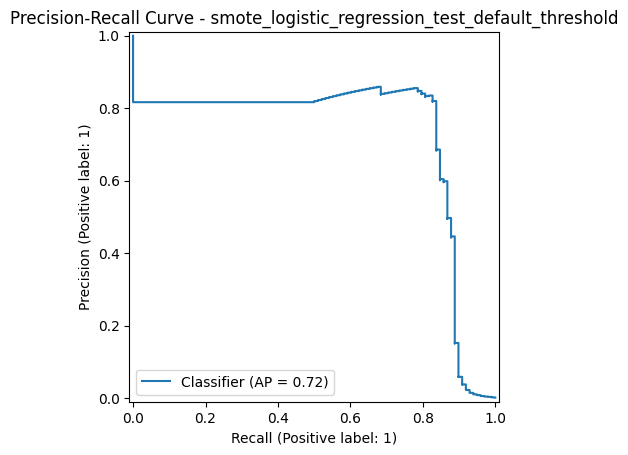



Đánh giá với selected threshold
===== smote_logistic_regression_test_tuned_threshold | threshold = 0.3200 =====
accuracy: 0.955093
balanced_accuracy: 0.936762
precision: 0.034091
recall: 0.918367
f1: 0.065741
roc_auc: 0.972005
pr_auc_avg_precision: 0.724059

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9552    0.9770     56864
           1     0.0341    0.9184    0.0657        98

    accuracy                         0.9551     56962
   macro avg     0.5170    0.9368    0.5214     56962
weighted avg     0.9982    0.9551    0.9754     56962



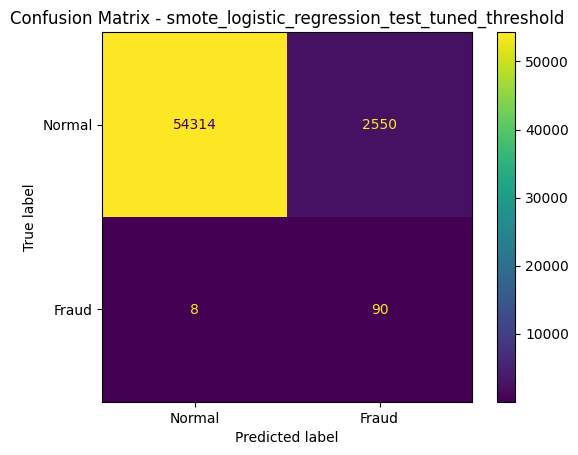

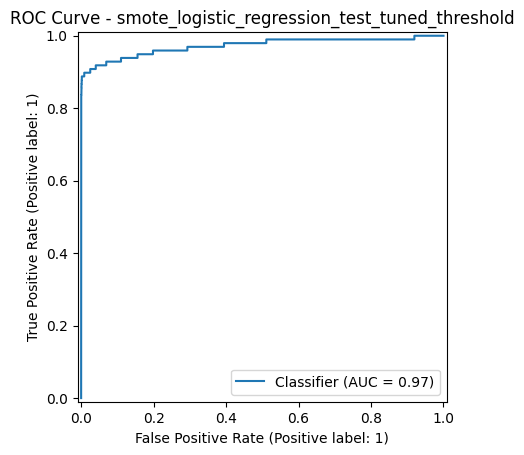

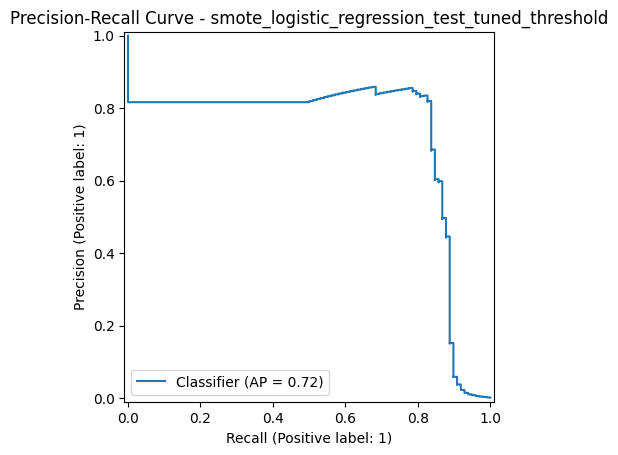

In [29]:
y_test_proba_candidate = candidate_model.predict_proba(X_test)[:, 1]

print("Đánh giá với threshold mặc định 0.5")
test_metrics_default = evaluate_predictions(
    y_test,
    y_test_proba_candidate,
    threshold=0.5,
    model_name=f"{CANDIDATE_MODEL_NAME}_test_default_threshold",
    plot=True,
)

print("\n\nĐánh giá với selected threshold")
test_metrics_tuned = evaluate_predictions(
    y_test,
    y_test_proba_candidate,
    threshold=selected_threshold,
    model_name=f"{CANDIDATE_MODEL_NAME}_test_tuned_threshold",
    plot=True,
)

In [30]:
test_compare = pd.DataFrame([test_metrics_default, test_metrics_tuned])
display(test_compare)

,model,threshold,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,pr_auc_avg_precision
0,smote_logistic_regression_test_default_threshold,0.50,0.974896,0.936494,0.058355,0.897959,0.109589,0.972005,0.724059
1,smote_logistic_regression_test_tuned_threshold,0.32,0.955093,0.936762,0.034091,0.918367,0.065741,0.972005,0.724059


# 20. Giải thích Confusion Matrix cho fraud detection

Confusion Matrix có 4 ô:

| Thành phần | Ý nghĩa trong fraud detection |
|---|---|
| TN | Giao dịch normal, model đoán normal |
| FP | Giao dịch normal, model báo fraud nhầm |
| FN | Giao dịch fraud, model bỏ sót |
| TP | Giao dịch fraud, model bắt đúng |

Trong fraud detection:

- **FN nguy hiểm**: fraud thật nhưng model bỏ qua.
- **FP gây tốn công**: giao dịch bình thường nhưng bị báo fraud.

Tùy mục tiêu, ta chọn threshold khác nhau:

- Ngân hàng muốn bắt fraud tối đa: ưu tiên Recall cao.
- Đội review ít người: cần Precision tốt hơn để giảm false alarms.

In [31]:
y_test_pred_tuned = (y_test_proba_candidate >= selected_threshold).astype(int)
cm = confusion_matrix(y_test, y_test_pred_tuned)

tn, fp, fn, tp = cm.ravel()

cm_explain = pd.DataFrame({
    "item": ["TN", "FP", "FN", "TP"],
    "count": [tn, fp, fn, tp],
    "meaning": [
        "Normal thật, model đoán Normal",
        "Normal thật, model báo Fraud nhầm",
        "Fraud thật, model bỏ sót",
        "Fraud thật, model bắt đúng",
    ]
})

display(cm_explain)

,item,count,meaning
0,TN,54314,"Normal thật, model đoán Normal"
1,FP,2550,"Normal thật, model báo Fraud nhầm"
2,FN,8,"Fraud thật, model bỏ sót"
3,TP,90,"Fraud thật, model bắt đúng"


# 21. Cross-validation với imbalanced data

Cross-validation giúp đánh giá model ổn định hơn.

Với imbalanced data, ta dùng `StratifiedKFold` để mỗi fold vẫn giữ tỷ lệ fraud gần giống nhau.

Lưu ý:

- Cross-validation có thể chạy lâu.
- Với SMOTE, phải đặt SMOTE bên trong pipeline để tránh data leakage.

In [32]:
RUN_CROSS_VALIDATION = True

if RUN_CROSS_VALIDATION:
    cv_model = ImbPipeline(steps=[
        ("preprocess", make_preprocessor()),
        ("smote", SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])
    
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
    scoring = {
        "roc_auc": "roc_auc",
        "pr_auc_avg_precision": "average_precision",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
    }
    
    cv_results = cross_validate(
        cv_model,
        X_train_temp,
        y_train_temp,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )
    
    cv_summary = pd.DataFrame({
        metric.replace("test_", ""): [values.mean(), values.std()]
        for metric, values in cv_results.items()
        if metric.startswith("test_")
    }, index=["mean", "std"]).T
    
    display(cv_summary)
else:
    print("Bỏ qua cross-validation vì RUN_CROSS_VALIDATION = False")

,mean,std
roc_auc,0.974456,0.008967
pr_auc_avg_precision,0.748212,0.024132
precision,0.056464,0.001379
recall,0.911134,0.013165
f1,0.106332,0.002433


# 22. Optional — Anomaly Detection với Isolation Forest

Phần này là hướng **unsupervised anomaly detection**.

Khác với Logistic Regression / Random Forest:

- Supervised model dùng label `Class` để học.
- Isolation Forest cố tìm điểm bất thường dựa trên feature, không cần label khi train.

Trong project này, label vẫn được dùng để đánh giá sau khi model dự đoán anomaly score.

Lưu ý:

- Isolation Forest không nhất thiết tốt hơn supervised model nếu bạn đã có label tốt.
- Nhưng nó giúp bạn hiểu hướng anomaly detection thật sự.

In [33]:
if RUN_ISOLATION_FOREST:
    contamination = float(y_train.mean())
    print("Estimated contamination:", contamination)
    
    iso_pipeline = SklearnPipeline(steps=[
        ("preprocess", make_preprocessor()),
        ("model", IsolationForest(
            n_estimators=200,
            contamination=contamination,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        )),
    ])
    
    iso_pipeline.fit(X_train)
    
    # decision_function càng thấp càng bất thường.
    # Ta đổi dấu để score càng cao nghĩa là càng nghi fraud.
    X_val_processed = iso_pipeline.named_steps["preprocess"].transform(X_val)
    iso_val_score = -iso_pipeline.named_steps["model"].decision_function(X_val_processed)
    
    iso_metrics = evaluate_predictions(
        y_val,
        iso_val_score,
        threshold=np.percentile(iso_val_score, 100 * (1 - contamination)),
        model_name="isolation_forest_validation",
        plot=True,
    )
else:
    print("Bỏ qua Isolation Forest vì RUN_ISOLATION_FOREST = False")

Bỏ qua Isolation Forest vì RUN_ISOLATION_FOREST = False


# 23. Feature importance / Model interpretation

Với Random Forest, ta có thể xem feature importance.

Với Logistic Regression, ta có thể xem coefficient.

Vì dataset đã PCA/anonymized, ta không giải thích được ý nghĩa business của `V1`, `V2`, ... nhưng vẫn biết feature nào ảnh hưởng mạnh hơn đến model.

,feature,coefficient,abs_coefficient
1,Amount,2.905713,2.905713
21,V20,-1.707074,1.707074
11,V10,-1.522079,1.522079
15,V14,-1.488727,1.488727
28,V27,-1.208895,1.208895
13,V12,-1.203309,1.203309
18,V17,-1.172225,1.172225
2,V1,1.084030,1.084030
6,V5,1.009715,1.009715
23,V22,0.976659,0.976659


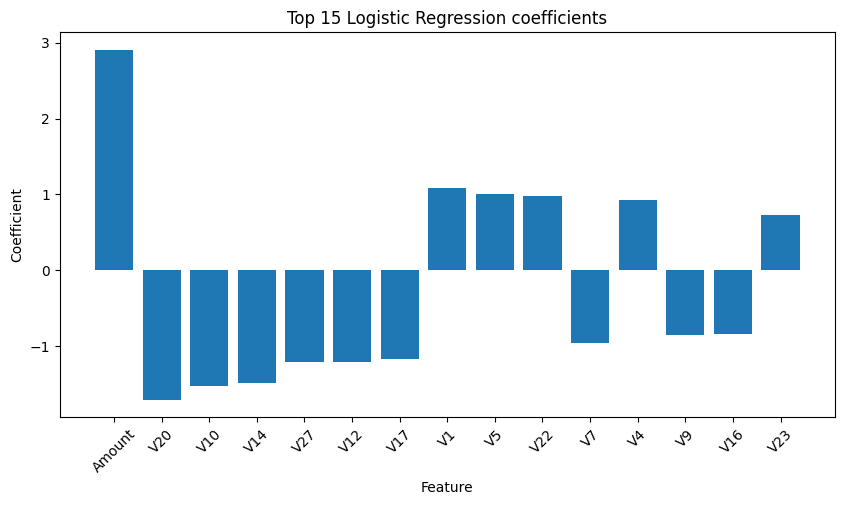

In [34]:
def get_feature_names_from_preprocessor(preprocessor, original_columns):
    try:
        return preprocessor.get_feature_names_out()
    except Exception:
        return original_columns

# Logistic Regression coefficients
if "logistic_regression_class_weight_balanced" in models:
    lr_model = models["logistic_regression_class_weight_balanced"]
    feature_names = get_feature_names_from_preprocessor(
        lr_model.named_steps["preprocess"],
        X.columns,
    )
    coef = lr_model.named_steps["model"].coef_[0]
    coef_df = pd.DataFrame({
        "feature": feature_names,
        "coefficient": coef,
        "abs_coefficient": np.abs(coef),
    }).sort_values("abs_coefficient", ascending=False)
    
    display(coef_df.head(15))
    
    plt.figure(figsize=(10, 5))
    plt.bar(coef_df.head(15)["feature"], coef_df.head(15)["coefficient"])
    plt.title("Top 15 Logistic Regression coefficients")
    plt.xlabel("Feature")
    plt.ylabel("Coefficient")
    plt.xticks(rotation=45)
    plt.show()

,feature,importance
15,V14,0.174437
13,V12,0.130371
12,V11,0.097809
5,V4,0.088629
11,V10,0.086639
18,V17,0.085491
4,V3,0.065579
17,V16,0.031190
3,V2,0.030450
8,V7,0.026186


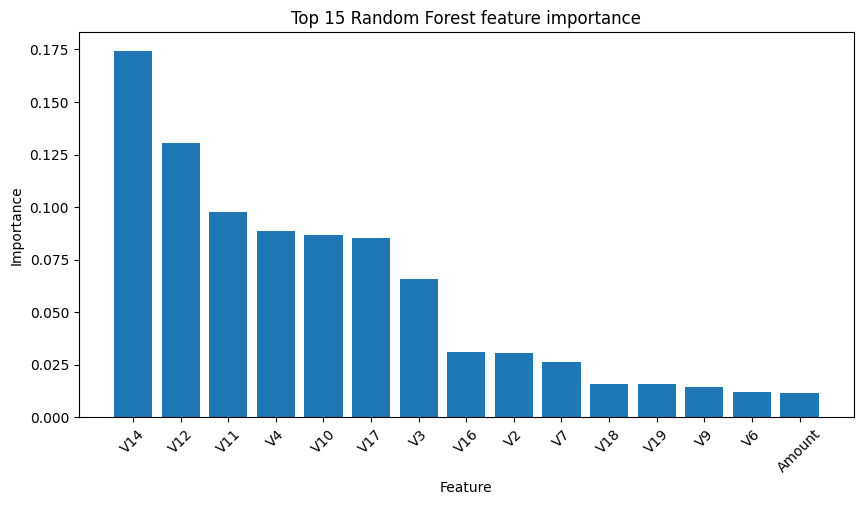

In [35]:
# Random Forest feature importance
if "random_forest_class_weight_balanced" in models:
    rf_model = models["random_forest_class_weight_balanced"]
    feature_names = get_feature_names_from_preprocessor(
        rf_model.named_steps["preprocess"],
        X.columns,
    )
    importances = rf_model.named_steps["model"].feature_importances_
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances,
    }).sort_values("importance", ascending=False)
    
    display(importance_df.head(15))
    
    plt.figure(figsize=(10, 5))
    plt.bar(importance_df.head(15)["feature"], importance_df.head(15)["importance"])
    plt.title("Top 15 Random Forest feature importance")
    plt.xlabel("Feature")
    plt.ylabel("Importance")
    plt.xticks(rotation=45)
    plt.show()
else:
    print("Không có Random Forest model để xem feature importance.")

# 24. Lưu model + threshold

Trong fraud detection, lưu model thôi chưa đủ.

Ta cần lưu thêm:

- selected threshold
- feature names
- model name
- metric cuối cùng

Vì khi predict transaction mới, ta không nên dùng threshold mặc định nếu đã tuning threshold.

In [36]:
artifact = {
    "model": candidate_model,
    "selected_threshold": selected_threshold,
    "selected_strategy": SELECTED_STRATEGY,
    "model_name": CANDIDATE_MODEL_NAME,
    "features": X.columns.tolist(),
    "test_metrics_default_threshold": test_metrics_default,
    "test_metrics_tuned_threshold": test_metrics_tuned,
}

model_path = MODEL_DIR / "fraud_detection" / "fraud_detection_model.pkl"
joblib.dump(artifact, model_path)

print("Đã lưu model artifact tại:", model_path)

Đã lưu model artifact tại: c:\Users\ASUS\Documents\PROJECT\intro_to_AI\models\fraud_detection\fraud_detection_model.pkl


# 25. Load model và predict thử một transaction

Đây là bước chuẩn bị cho deployment sau này.

Pipeline predict thực tế:

```text
Transaction mới
-> đưa vào DataFrame đúng format feature
-> model.predict_proba()
-> so sánh với selected_threshold
-> output Normal/Fraud
```

In [37]:
loaded_artifact = joblib.load(model_path)
loaded_model = loaded_artifact["model"]
loaded_threshold = loaded_artifact["selected_threshold"]
loaded_features = loaded_artifact["features"]

print("Loaded model:", loaded_artifact["model_name"])
print("Loaded threshold:", loaded_threshold)

Loaded model: smote_logistic_regression
Loaded threshold: 0.32


In [38]:
def predict_transaction(transaction_df, artifact):
    '''Predict one or many transactions.
    
    Parameters
    ----------
    transaction_df : pd.DataFrame
        DataFrame chứa đúng các feature như training data.
    artifact : dict
        Object đã load từ fraud_detection_model.pkl.
    
    Returns
    -------
    pd.DataFrame
        Fraud probability và prediction label.
    '''
    model = artifact["model"]
    threshold = artifact["selected_threshold"]
    features = artifact["features"]
    
    transaction_df = transaction_df[features].copy()
    fraud_proba = model.predict_proba(transaction_df)[:, 1]
    prediction = (fraud_proba >= threshold).astype(int)
    
    result = pd.DataFrame({
        "fraud_probability": fraud_proba,
        "threshold": threshold,
        "prediction": prediction,
        "prediction_label": np.where(prediction == 1, "Fraud", "Normal"),
    })
    return result

# Lấy thử 5 transaction từ test set
sample_transactions = X_test.head(5)
predict_transaction(sample_transactions, loaded_artifact)

,fraud_probability,threshold,prediction,prediction_label
0,3.467588e-04,0.32,0,Normal
1,2.758099e-02,0.32,0,Normal
2,1.921961e-08,0.32,0,Normal
3,6.711649e-03,0.32,0,Normal
4,9.862119e-01,0.32,1,Fraud


# 26. Kết luận project

Sau khi chạy xong notebook, bạn cần tự trả lời được các câu hỏi sau:

1. Dataset bị imbalance nặng như thế nào?
2. Vì sao Accuracy không đủ để đánh giá fraud detection?
3. Model nào có PR-AUC tốt nhất trên validation set?
4. Threshold tuning làm Precision/Recall thay đổi ra sao?
5. Nếu bạn là ngân hàng, bạn chọn threshold nào và vì sao?
6. SMOTE có giúp model tốt hơn không? Tốt hơn ở metric nào?
7. Model cuối cùng có bỏ sót fraud nhiều không?

---

## Gợi ý báo cáo ngắn

Bạn có thể viết report theo format:

```text
1. Problem Statement
2. Dataset Overview
3. Imbalanced Data Analysis
4. EDA
5. Models Trained
   - Always Normal Baseline
   - Logistic Regression
   - Logistic Regression + Class Weight
   - Logistic Regression + SMOTE
   - Random Forest + Class Weight
6. Evaluation Metrics
   - Precision
   - Recall
   - F1-score
   - ROC-AUC
   - PR-AUC
7. Threshold Tuning
8. Final Model Selection
9. Limitations
10. Next Steps
```

---

## Next steps nếu muốn nâng cấp Project 4

Sau version 1, bạn có thể nâng cấp:

1. Dùng `GridSearchCV` / `RandomizedSearchCV`.
2. Thử `XGBoost`, `LightGBM`, `CatBoost`.
3. Dùng undersampling + SMOTE kết hợp.
4. Calibrate probability bằng `CalibratedClassifierCV`.
5. Tạo FastAPI endpoint:

```text
POST /predict-fraud
Input: transaction features
Output: fraud_probability, prediction
```

6. Tạo Streamlit dashboard để xem fraud probability.

# 27. Bài tập tự luyện

Bạn làm các câu này sau khi chạy notebook:

1. Đổi `TARGET_RECALL` từ `0.90` sang `0.95`. Precision thay đổi thế nào?
2. So sánh threshold `0.5` và threshold tuned. Cái nào bắt được nhiều fraud hơn?
3. Tắt SMOTE và chỉ dùng `class_weight='balanced'`. Model nào có PR-AUC tốt hơn?
4. Với Random Forest, thử đổi `n_estimators` từ 150 lên 300. Kết quả có cải thiện không?
5. Viết một đoạn markdown giải thích vì sao `PR-AUC` quan trọng hơn Accuracy trong project này.
6. Lưu kết quả cuối cùng vào file `fraud_detection_results.csv`.
7. Tự viết hàm nhận một transaction và in ra câu:

```text
This transaction is likely Fraud with probability = ...
```